In [2]:
from matplotlib import pyplot as plt
import gymnasium as gym
import numpy as np
import envs
from sklearn.neighbors import KernelDensity
from pathlib import Path

from learners import *
from analysis import *
from dist_run import *
from display_qtables import *

def get_tau(N): return (np.arange(N) + 0.5) / N

def get_kde(q, bandwidth):
    samples = q[:, None]
    kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth).fit(samples)
    return_kde = lambda x: np.exp(kde.score_samples(x[:, None]))
    return return_kde

In [3]:
class QuantileRegression():
    def __init__(self, params, init_theta=None):
        self.learning_rate = params.learning_rate
        self.gamma = params.gamma
        self.state_size = params.state_size
        self.action_size = params.action_size
        self.n_quantiles = params.n_quantiles
        self.k = params.huber_k
        self.init_theta = init_theta.copy()
        self.reset_table()
        self.tau = (np.arange(self.n_quantiles) + 0.5) / self.n_quantiles

    def _rho(self, u):
        if self.k==0.0:
            return -(self.tau - (u < 0))
        else:
            return -np.abs(self.tau - (u < 0)) * du_huber(u, self.k)

    def update(self, state, action, reward, new_state):
        pred_quantiles = self.theta[state, action]
        greedy_action = self.theta[new_state].mean(1).argmax()
        target_quantiles = reward + self.gamma * self.theta[new_state, greedy_action]
        
        u = target_quantiles[:, None] - pred_quantiles[None, :]
        self.theta[state, action] -= self.learning_rate * self._rho(u).mean(0)

    def reset_table(self):
        """Reset the theta values."""
        if self.init_theta is not None:
            self.theta = self.init_theta.copy()
        else:
            self.theta = np.zeros((self.state_size, self.action_size, self.n_quantiles))

    def get_qtable(self):
        return self.theta.mean(2)
    
    def get_table(self):
        return self.theta.copy()

    def set_learning_rate(self, learning_rate):
        self.learning_rate = learning_rate

In [4]:
params = Params(
    model_name="CliffMini",
    total_episodes=10_000,
    save_skip=10,
    n_runs=1,
    seed=123,
    
    lr_decay=2000,
    learning_rate=1.0,

    gamma=0.99,
    epsilon=0.10,
    huber_k=0.0,
    n_quantiles=32,
    
    action_size=None,
    state_size=None,
    map_size=None,
    learner_name=None,
)
rng = np.random.default_rng(params.seed)
tau = get_tau(params.n_quantiles)

env = gym.make(
    params.model_name, render_mode="rgb_array",
    reward_variance=0.25,
    shape=(2,3),
)
env.action_space.seed(params.seed)
params = params._replace(action_size=int(env.action_space.n))
params = params._replace(state_size=int(env.observation_space.n))
params = params._replace(map_size=env.unwrapped.shape)
s_init = env.unwrapped.start_state_index

save_to = "experiments/"+params.model_name.replace("-v1","")
Path(save_to).mkdir(parents=True, exist_ok=True)

init_theta = np.full((params.state_size, params.action_size, params.n_quantiles), 0.0)

In [5]:
policy, V = PolicyIteration(env, params.gamma)
returns = MonteCarlo(env, policy, params, s_init, rng, total_episodes=25_000)
explorer = EpsilonGreedy(params.epsilon, rng, policy=policy)
tau_returns = np.quantile(returns, tau)

100%|██████████| 25000/25000 [00:05<00:00, 4574.71it/s]


In [26]:
params_simple = params._replace(huber_k=0.0)
tables_run = run_env(env, QuantileRegression(params_simple, init_theta), explorer, params_simple)
a_max = tables_run.mean((0,-1))[-1,s_init].argmax()
q_simple = tables_run[:,:,s_init,a_max]
best_simple = q_simple.mean(0)[-1]

100%|██████████| 5000/5000 [00:12<00:00, 406.53it/s, ep=5000, run=1]


In [6]:
def du_huber(u, k=1.0):
    return np.where(np.abs(u) <= k, u / k, k * np.sign(u))

class QR1(QuantileRegression):
    def _rho(self, u):
        weight = -np.abs(self.tau[None, :] - (u < 0)) * du_huber(u, self.k)
        return weight
    
class QR2(QuantileRegression):
    def update(self, state, action, reward, new_state):
        pred_quantiles = self.theta[state, action]
        greedy_action = self.theta[new_state].mean(1).argmax()
        target_quantiles = reward + self.gamma * self.theta[new_state, greedy_action]
        
        u = target_quantiles[:, None] - pred_quantiles[None, :]
        rho = (np.abs((tau - (u < 0))) * du_huber(u.mean(0), 1.0)).mean(0)
        self.theta[state, action] -= self.learning_rate * -rho
class QR3(QuantileRegression):
    def update(self, state, action, reward, new_state):
        pred_quantiles = self.theta[state, action]
        greedy_action = self.theta[new_state].mean(1).argmax()
        target_quantiles = reward + self.gamma * self.theta[new_state, greedy_action]
        
        u = target_quantiles[:, None] - pred_quantiles[None, :]
        rho = np.abs((tau - (u.mean(0) < 0))) * du_huber(u.mean(0), 1.0)
        self.theta[state, action] -= self.learning_rate * -rho
class QR4(QuantileRegression):
    def update(self, state, action, reward, new_state):
        pred_quantiles = self.theta[state, action]
        greedy_action = self.theta[new_state].mean(1).argmax()
        target_quantiles = reward + self.gamma * self.theta[new_state, greedy_action]
        
        u = target_quantiles[:, None] - pred_quantiles[None, :]
        rho = np.abs((tau - (u < 0)).mean(0)) * du_huber(u, 1.0).mean(0)
        self.theta[state, action] -= self.learning_rate * -rho
class QR5(QuantileRegression):
    def update(self, state, action, reward, new_state):
        pred_quantiles = self.theta[state, action]
        greedy_action = self.theta[new_state].mean(1).argmax()
        target_quantiles = reward + self.gamma * self.theta[new_state, greedy_action]
        
        u = target_quantiles[:, None] - pred_quantiles[None, :]
        rho = np.abs((tau - (u < 0))).mean(0) * du_huber(u, 1.0).mean(0)
        self.theta[state, action] -= self.learning_rate * -rho
class QR6(QuantileRegression):
    def update(self, state, action, reward, new_state):
        pred_quantiles = self.theta[state, action]
        greedy_action = self.theta[new_state].mean(1).argmax()
        target_quantiles = reward + self.gamma * self.theta[new_state, greedy_action]
        
        u = target_quantiles[:, None] - pred_quantiles[None, :]
        rho = np.abs((tau - (u < 0))).mean(0) * du_huber(u.mean(0), 1.0)
        self.theta[state, action] -= self.learning_rate * -rho

In [58]:
tabl = (run_env(env, QR1(params_hub, init_theta), explorer, params_hub))
tablers[0] = tabl
a_max = tabl.mean((0,-1))[-1,s_init].argmax()
q_hub = tabl[:,:,s_init,a_max]
best_hub = q_hub.mean(0)[-1]
besters[0] = best_hub

100%|██████████| 5000/5000 [00:12<00:00, 399.03it/s, ep=5000, run=1]


In [7]:
params_hub = params._replace(huber_k=1.0)
tablers = []

besters = []
for lrnr in [QR1, QR2, QR3, QR4, QR5, QR6]:
    tabl = (run_env(env, lrnr(params_hub, init_theta), explorer, params_hub))
    tablers.append(tabl)
    a_max = tabl.mean((0,-1))[-1,s_init].argmax()
    q_hub = tabl[:,:,s_init,a_max]
    best_hub = q_hub.mean(0)[-1]
    besters.append(best_hub)

100%|██████████| 10000/10000 [00:19<00:00, 500.14it/s, ep=1e+4, run=1]


In [6]:
params_q = params._replace(n_quantiles=1)
tables_run_q = run_env(env, Qlearning(params_q), explorer, params_q)
a_max_q = tables_run_q.mean((0,-1))[-1,s_init].argmax()
q_q = tables_run_q[:,:,s_init,a_max_q]
best_q = q_q.mean(0)[-1]

100%|██████████| 30000/30000 [00:53<00:00, 562.04it/s, ep=3e+4, run=1] 


In [594]:
def du_huber(u, k=1.0):
    return np.where(np.abs(u) <= k, u / k, k * np.sign(u))

N = 200
theta = np.zeros(N)
s = 0
tau = get_tau(N)

for _ in range(10000):
    pred_quantiles = theta
    target_quantiles = np.random.randn(N)
    u = target_quantiles[:, None] - pred_quantiles[None, :]

    res1 = (tau - (u < 0)).mean(0)

    res2 = (np.abs((tau - (u < 0))) * du_huber(u, 1.0)).mean(0)

    res3 = (np.abs((tau - (u < 0))) * du_huber(u.mean(0), 1.0)).mean(0)
    
    
    # res2 = np.abs((tau - (u.mean(0) < 0))) * du_huber(u.mean(0), 1.0)

    # res1 = np.abs((tau - (u < 0)).mean(0)) * du_huber(u, 1.0).mean(0)

    # res4 = np.abs((tau - (u < 0))).mean(0) * du_huber(u, 1.0).mean(0)

    # res5 = np.abs((tau - (u < 0))).mean(0) * du_huber(u.mean(0), 1.0)

    s += 1
    lr = 0.05 * 1 / np.sqrt(s+1)
    theta -= lr * res1

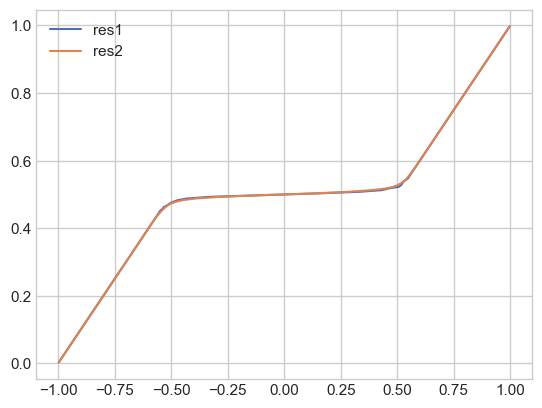

In [595]:
plt.plot(res1, tau, label="res1")
plt.plot(res2, tau, label="res2")
# plt.plot(res3, tau, label="res3")
# plt.plot(res4, tau, label="res4")
# plt.plot(res5, tau, label="res5")
# plt.plot(res6, tau, label="res6")
plt.legend()

In [ ]:
N = 64
theta = np.zeros(N)
tau = (np.arange(N) + 0.5) / N

for k in tqdm(range(1000)):
    Ttheta = np.random.randn() + np.zeros(N)
    
    g = np.zeros(N)
    for i in range(N):
        for j in range(N):
            u = Ttheta[j] - theta[i]
            g[i] += -np.abs(tau[i] - (u < 0)) * du_huber(u, 0.5) / N
    
    # S = len(Ttheta)
    # g = np.zeros((len(theta),))
    # for y in Ttheta:
    #     for i, tt in enumerate(theta):
    #         u = y - theta[i]
    #         g[i] += 1 / S * (-1) * (tau[i] - (u < 0))
    
    theta -= (1/(k+1))**0.5 * g

100%|██████████| 1000/1000 [00:18<00:00, 53.65it/s]


In [8]:
W1 = lambda truth, estimate: abs(truth - estimate).mean(-1)
VSE = lambda z1, z2: (z1.mean(-1) - z2.mean(-1))**2

vd     = W1(tau_returns, q_simple)
vd_hub = W1(tau_returns, q_hub)

vf     = VSE(tau_returns, q_simple)
vf_hub = VSE(tau_returns, q_hub)
vf_q   = VSE(tau_returns, q_q)

NameError: name 'q_simple' is not defined

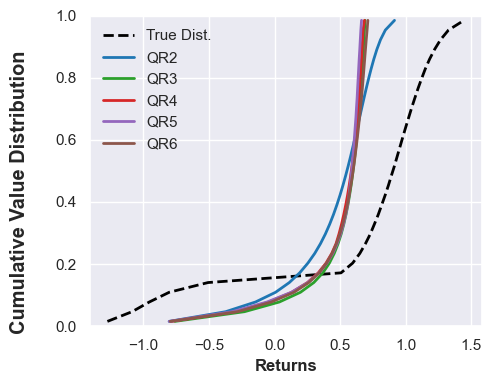

In [9]:
fig, ax = plt.subplots(figsize=(5,4))
plt.style.use("seaborn-v0_8-whitegrid")
fig.supylabel("Cumulative Value Distribution", fontweight="bold")

# ax.plot(best_simple, tau, label="Simple", linewidth=2, color="#FF2E0E")
# ax.plot(best_hub, tau, label="Huber", linewidth=2, color="#1394DE")
ax.plot(tau_returns, tau, label="True Dist.", linestyle="--", linewidth=2, color="black")

for b, lab, col in zip(besters, 
                       ["QR2", "QR3", "QR4", "QR5", "QR6"],
                       ["#1f77b4", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]):
    ax.plot(b, tau, label=lab, linewidth=2, color=col)

ax.set_ylim(0.0,1.0)
ax.set_xlabel("Returns", fontweight="bold")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig(f"{save_to}/cdf_compare.pdf", format="pdf", bbox_inches="tight")
plt.show()

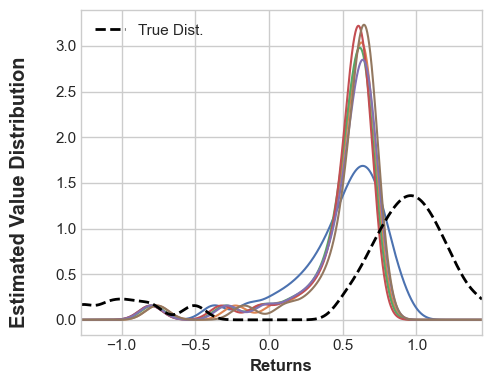

In [12]:
fig, ax = plt.subplots(figsize=(5,4))
plt.style.use("seaborn-v0_8-whitegrid")
fig.supylabel("Estimated Value Distribution", fontweight="bold")

aller = np.array([tau_returns])
lims = (aller.min(), aller.max())
Xs = np.linspace(*lims, 10_000)
bw = 0.08

# ax.plot(Xs, get_kde(best_simple, bandwidth=bw)(Xs), label="Simple", linewidth=2, color="#FF2E0E")
# ax.plot(Xs, get_kde(best_hub, bandwidth=bw)(Xs), label="Huber", linewidth=2, color="#1394DE")

for b in besters:
    ax.plot(Xs, get_kde(b, bandwidth=bw)(Xs))

ax.plot(Xs, get_kde(tau_returns, bandwidth=bw)(Xs), label="True Dist.", linestyle="--", linewidth=2, color="black")

ax.set_xlim(*lims)
ax.set_xlabel("Returns", fontweight="bold")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig(f"{save_to}/pdf_compare.pdf", format="pdf", bbox_inches="tight")
plt.show()

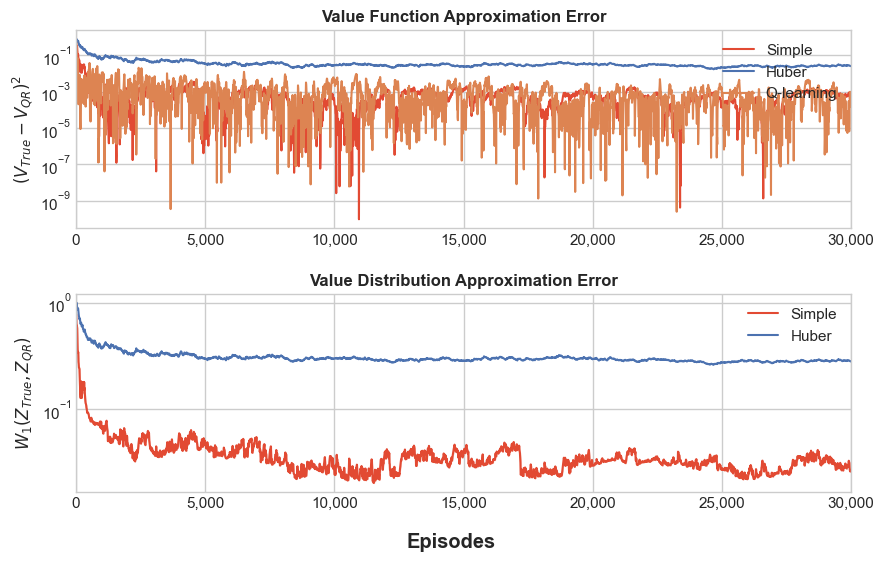

In [605]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(10,6), gridspec_kw={'hspace': 0.33})
fig.supxlabel("Episodes", fontweight="bold")

# X = range(params.total_episodes//params.save_skip)
X = range(q_simple.shape[1])

axes[1].plot(vd.mean(0), label="Simple", color="#E24A33")
axes[1].plot(vd_hub.mean(0), label="Huber")
axes[1].fill_between(X, vd.mean(0) - vd.std(0), vd.mean(0) + vd.std(0), alpha=0.3, color="#E24A33")
axes[1].fill_between(X, vd_hub.mean(0) - vd_hub.std(0), vd_hub.mean(0) + vd_hub.std(0), alpha=0.3)

axes[1].set_title("Value Distribution Approximation Error", fontweight="bold")
axes[1].set_ylabel("$ W_1(Z_{True}, Z_{QR}) $")
axes[1].set_yscale("log")
ticks = axes[1].get_xticks().astype(int)
axes[1].set_xticks(ticks, [f"{x:,}" for x in ticks*params.save_skip])
axes[1].set_xlim(ticks[1], ticks[-2])
axes[1].legend(loc=1)


axes[0].plot(vf.mean(0), label="Simple", color="#E24A33")
axes[0].plot(vf_hub.mean(0), label="Huber")
axes[0].plot(vf_q.mean(0), label="Q-learning")

axes[0].set_title("Value Function Approximation Error", fontweight="bold")
axes[0].set_ylabel("$ (V_{True} - V_{QR} )^2 $")
axes[0].set_yscale("log")
axes[0].set_xticks(ticks, [f"{x:,}" for x in ticks*params.save_skip])
axes[0].set_xlim(ticks[1], ticks[-2])
axes[0].legend(loc=1)

plt.savefig(f"{save_to}/true_compare.pdf", format="pdf", bbox_inches="tight")
plt.show()